In [1]:
# %load_ext autoreload
# %autoreload 2

import torch
from torch import nn
from torch.utils.data import random_split, DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor

import os
import pandas as pd
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from torchvision.transforms import ToTensor, Lambda
import matplotlib.colors as mcolors

from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
import sys
sys.path.insert(0, '../')
from utils import *
import matplotlib.pyplot as plt
import wandb
import datetime

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sn
import numpy as np
import matplotlib.colors as mcolors
from matplotlib import rc
plt.rc("text", usetex=True)  # Enable LaTeX
os.environ["PATH"] += os.pathsep + "/software/texlive/2015/bin/x86_64-linux/"
from matplotlib.lines import Line2D

## Confusion Matrix Comparison ##

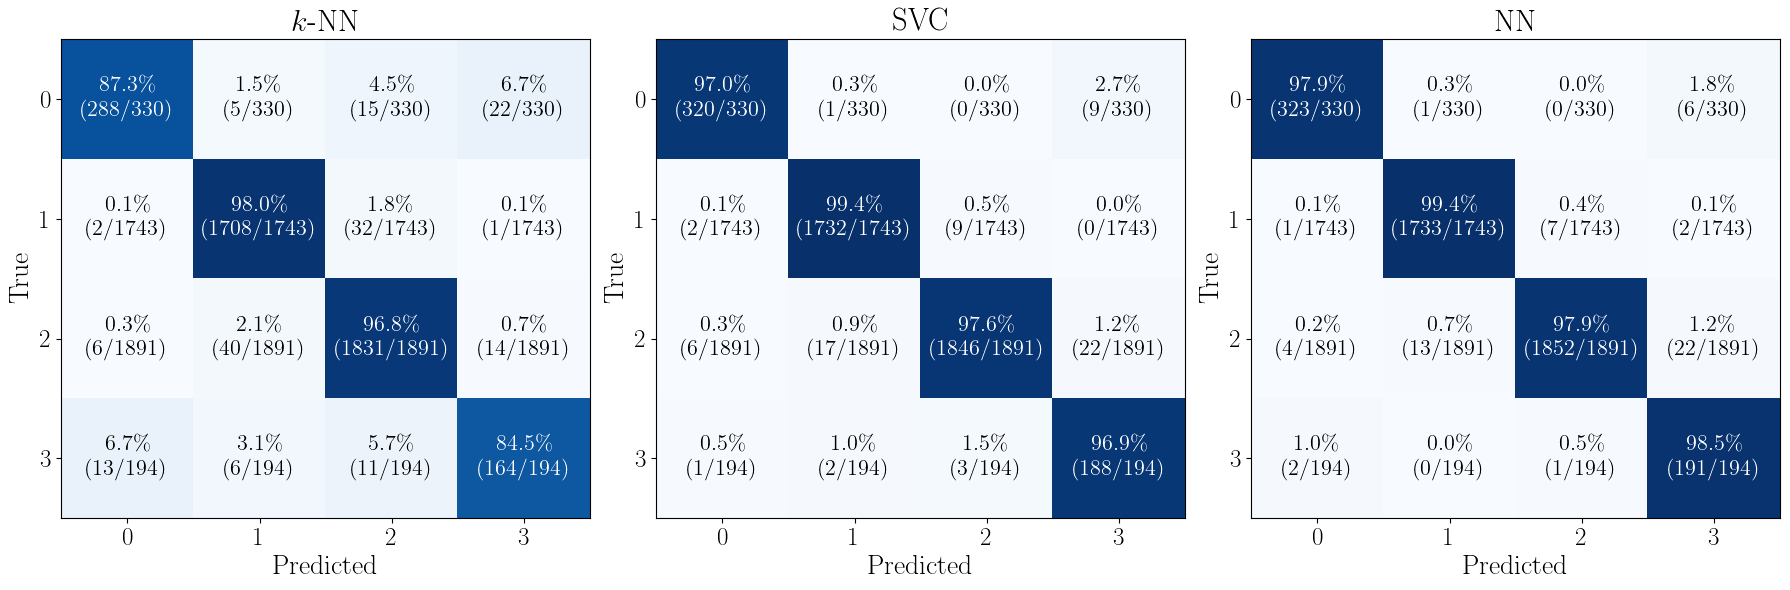

In [3]:
#-- Load the data 
data = np.load('../data_splits_splot22f_1215.npz')
X_train = data['X_train']
y_train = data['y_train'][:, :1].flatten().astype(int)
X_val = data['X_val']
y_val = data['y_val'][:, :1].flatten().astype(int)
X_test = data['X_test']
y_test = data['y_test'][:, :1].flatten().astype(int)

# Create panel with all three
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

#-- Load the kNN model 

knn_results = np.load('results/knn_results.npz', allow_pickle=True)
y_pred_knn = knn_results['y_pred_test']
gen_confusion_matrix(y_test, y_pred_knn, r"$k$-$\rm NN$", ax=axes[0])

#-- Load the SVM model 

svm_results = np.load('results/svm_results.npz', allow_pickle=True)
y_pred_svm = svm_results['y_pred_test']
gen_confusion_matrix(y_test, y_pred_svm,  r'$\rm SVC $', ax=axes[1])

# -- Load the NN model 
NN_results = np.load('results/NN_results.npz', allow_pickle=True)
y_pred_NN = NN_results['y_pred_test']
gen_confusion_matrix(y_test, y_pred_NN, r'$\rm NN$', ax=axes[2])

plt.tight_layout()
fig.savefig('../figures/confusion_matrices_panel.pdf', dpi=300, bbox_inches='tight')
plt.show()


## Missclassifications ##

In [3]:
def N_gridsearch_plotter_missclassified(ax, X_train, y_train, X_test, y_test, X_val, y_val, model, scaler, feature_idx, fixed_values={}, labels = [], method = 'NN', num_classes = 4, legends = [True, True]):
    """
    Plots the decision boundary for a PyTorch model using a 2D slice of a higher-dimensional space.
    
    Parameters:
    - X_train, X_test, X_val: float arrays, containing (unnormalized) data for training, testing, and validation sets 
    - y_train, y_test, y_val: float arrays, containing (unnormalized) labels for training, testing, and validation sets 
    - model: Trained model.
    - scaler: to be used to transfor the data into the format taken by the model
    - feature_idx: Tuple (i, j) specifying which two features to plot.
    - fixed_values: Dictionary {feature_index: value} for fixing other dimensions. Unnormalized (same format as train/test/val tests)
    - labels:  list of strings 
    - method: method to evaluate
    """

    # Step 1: Filter train and test data based on fixed_values

    train_mask = np.logical_and.reduce([np.isclose(X_train[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    val_mask = np.logical_and.reduce([np.isclose(X_val[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    test_mask = np.logical_and.reduce([np.isclose(X_test[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    
    if (train_mask.sum() == 0 and test_mask.sum() == 0 and val_mask.sum() == 0):
        print("No data points!")
        return None

    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_val_filtered, y_val_filtered = X_val[val_mask], y_val[val_mask]
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]
    
    # Step 2: Create a meshgrid for the chosen two features
    
    x_min, x_max = X_train_filtered[:, feature_idx[0]].min() - 0.1, X_train_filtered[:, feature_idx[0]].max() + 0.1
    y_min, y_max = X_train_filtered[:, feature_idx[1]].min() - 0.1, X_train_filtered[:, feature_idx[1]].max() + 0.1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

    # Step 4: Standard normalize the data like you did before
    fixed_values_norm = {}
    if method == 'SVC' or method == 'kNN':
        xx_norm = (xx - scaler.mean_[feature_idx[0]]) / scaler.scale_[feature_idx[0]]
        yy_norm = (yy - scaler.mean_[feature_idx[1]]) / scaler.scale_[feature_idx[1]]

        # Scale the fixed values according to the method
        for k, v in fixed_values.items():
            fixed_values_norm[k] = (v - scaler.mean_[k]) / scaler.scale_[k]
        
    elif method == 'NN':
        train_mean = scaler[0]
        train_std = scaler[1]
        xx_norm = (xx - train_mean[feature_idx[0]]) / train_std[feature_idx[0]]
        yy_norm = (yy - train_mean[feature_idx[1]]) / train_std[feature_idx[1]]

        # Scale the fixed values according to the method
        for k, v in fixed_values.items():
            fixed_values_norm[k] = (v - train_mean[k]) / train_std[k]

    # Step 3: Construct full-dimensional input space for predictions
    X_vis = torch.zeros((xx_norm.ravel().shape[0], X_train.shape[1]), dtype=torch.float32)
    X_vis[:, feature_idx[0]] = torch.tensor(xx_norm.ravel(), dtype=torch.float32)
    X_vis[:, feature_idx[1]] = torch.tensor(yy_norm.ravel(), dtype=torch.float32)

    # Assign fixed values to other dimensions
    for k, v in fixed_values_norm.items():
        X_vis[:, k] = v

    # Step 4: Predict labels for meshgrid

    if method == 'SVC' or method == 'kNN':
        Z = model.predict(X_vis)
    elif method == 'NN':
        model.eval()
        with torch.no_grad():
            Z = model(X_vis).argmax(dim=1).numpy()

    Z = Z.reshape(xx.shape)

    # NEW: Get predictions for test set to identify misclassifications
    X_test_norm = torch.zeros((X_test_filtered.shape[0], X_train.shape[1]), dtype=torch.float32)
    X_test_norm[:, feature_idx[0]] = torch.tensor((X_test_filtered[:, feature_idx[0]] - scaler.mean_[feature_idx[0]]) / scaler.scale_[feature_idx[0]] if method == 'SVC' or method == 'kNN' else (X_test_filtered[:, feature_idx[0]] - train_mean[feature_idx[0]]) / train_std[feature_idx[0]], dtype=torch.float32)
    X_test_norm[:, feature_idx[1]] = torch.tensor((X_test_filtered[:, feature_idx[1]] - scaler.mean_[feature_idx[1]]) / scaler.scale_[feature_idx[1]] if method == 'SVC' or method == 'kNN' else (X_test_filtered[:, feature_idx[1]] - train_mean[feature_idx[1]]) / train_std[feature_idx[1]], dtype=torch.float32)
    
    for k, v in fixed_values_norm.items():
        X_test_norm[:, k] = v
    
    if method == 'SVC' or method == 'kNN':
        y_test_pred = model.predict(X_test_norm)
    elif method == 'NN':
        model.eval()
        with torch.no_grad():
            y_test_pred = model(X_test_norm).argmax(dim=1).numpy()
    
    # Identify misclassified test points
    misclassified_mask = (y_test_pred != y_test_filtered)

    # Normalize color mapping to match the scatter points and contour
    cmap = plt.cm.coolwarm  # Set the same colormap
    norm = mcolors.Normalize(vmin=0, vmax=2)  # Normalize colors

    if num_classes > 3: 

        # Define your own hex colors for each label
        hex_colors = ['lightgrey', '#386FA4', '#678D58', '#8E3B46'] # grey, blue, green, red

        # Create a discrete colormap from your chosen colors
        cmap = mcolors.ListedColormap(hex_colors)

        # Define the normalization so labels 0–3 map to your colors
        norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5], ncolors=len(hex_colors))



    # Step 5: Plot decision boundary
    ax.contourf((10**xx-0.1), np.log10(10**yy - 10), Z, alpha=0.5, cmap=cmap, norm=norm)
  
    ax.scatter((10**X_train_filtered[:, feature_idx[0]] -0.1) ,np.log10(10**X_train_filtered[:, feature_idx[1]] - 10), c=y_train_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='o')
    ax.scatter((10**X_val_filtered[:, feature_idx[0]] -0.1) , np.log10(10**X_val_filtered[:, feature_idx[1]]- 10), c=y_val_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='s')
    ax.scatter((10**X_test_filtered[:, feature_idx[0]]-0.1)  , np.log10(10**X_test_filtered[:, feature_idx[1]]- 10), c=y_test_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='^' )
    
    # NEW: Mark misclassified test points with red crosses
    if misclassified_mask.sum() > 0:
        ax.scatter((10**X_test_filtered[misclassified_mask, feature_idx[0]]-0.1), 
                   np.log10(10**X_test_filtered[misclassified_mask, feature_idx[1]]- 10), 
                   marker='x', s=100, c='red', linewidths=2, label='Misclassified')
    
    ax.set_xlabel(fr" {labels[0]}", fontsize = 15)
    ax.set_ylabel(fr" {labels[1]}", fontsize = 15)
    ax.tick_params(axis='both', which='major', labelsize=13)  # or any size you prefer
    # ax.set_title(fr"$\mathrm{{T}} = {round((float(labels[4])),3)}\ \mathrm{{Gyr}}, \, \mathrm{{M_1}} = {labels[2]}\ M_\odot,\ \mathrm{{M_2}} = {labels[3]}\ M_\odot $", fontsize = 20)
    ax.set_title(fr"$\mathrm{{T}} = {round((float(labels[4])),5)}\ \mathrm{{Gyr}}, \, \mathrm{{M_1}} = {labels[2]}\ M_\odot,\ \mathrm{{M_2}} = {labels[3]}\ M_\odot $", fontsize = 20)


    # --- Y axis custom ticks ---
    ax.set_yticks([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0])    
    ax.set_yticklabels([r'$1.0$', r'$1.5$', r'$2.0$', r'$2.5$', r'$3.0$', r'$3.5$', r'$4.0$'])   

    # --- Small ticks inside the plot ---
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', direction='in', length=6, labelsize=13)
    ax.tick_params(axis='both', which='minor', direction='in', length=3)  # smaller minor ticks

    if legends[0]:
        legend_elements = [
        Line2D([0], [0], marker='o', color='k', label=r'$\rm Train$', linestyle='None', markersize=5),
        Line2D([0], [0], marker='s', color='k', label=r'$\rm Val$',   linestyle='None', markersize=5),
        Line2D([0], [0], marker='^', color='k', label=r'$\rm Test$',  linestyle='None', markersize=5),]

        ax.legend(handles=legend_elements, fontsize=15)#20
    if legends[1]:
        legend_elements = [
        Line2D([0], [0], marker='o', color='lightgrey', label=r'$0$', linestyle='None', markersize=5),
        Line2D([0], [0], marker='o', color='#386FA4', label=r'$1$',   linestyle='None', markersize=5),
        Line2D([0], [0], marker='o', color='#678D58', label=r'$2$',  linestyle='None', markersize=5),
        Line2D([0], [0], marker='o', color='#8E3B46', label=r'$3$',  linestyle='None', markersize=5),]

        ax.legend(handles=legend_elements, title = r"$ \rm Class $", title_fontsize = 16, fontsize=15, loc = 'lower left') 
    # plt.tight_layout()
    return ax

(22, 5)
(22, 1)
************************************************************


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray._reconstruct was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray._reconstruct])` or the `torch.serialization.safe_globals([numpy._core.multiarray._reconstruct])` context manager to allowlist this global if you trust this class/function.

Check the documentation of to

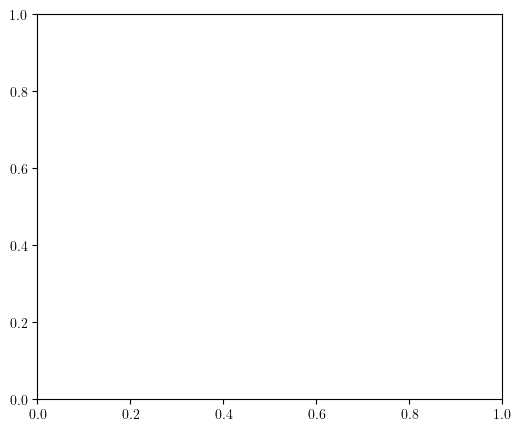

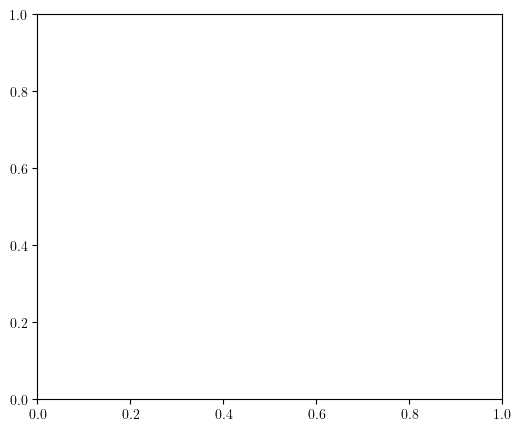

In [4]:
# Which are missclassified?

# Ground Truth
data = np.load('../data_splits_splot22f_1215.npz')
X_test = data['X_test']
y_test = data['y_test'][:, :1].flatten().astype(int)

# Predictions Truth
NN_results = np.load('results/NN_results.npz', allow_pickle=True)
y_pred_NN = NN_results['y_pred_test']

# Looking at specific points classified as 3 but actually 2
misses = np.argwhere((y_test == 2) & (y_pred_NN == 3))

X_test_missclassified = X_test[misses].squeeze(axis=1)
y_test_missclassified = y_test[misses]

print(np.shape(X_test_missclassified))
print(np.shape(y_test_missclassified))
num_panels = 1
methods = ['NN']
num_rows = len(methods)
num_cols = num_panels

# Create figure and axes grid with only shared y-axis
fig, axes = plt.subplots(num_rows, num_cols, 
                         figsize=(6*num_cols, 5*num_rows), 
                         sharey=True)

# Ensure axes is 2D array
if num_rows == 1:
    axes = np.expand_dims(axes, 0)
if num_cols == 1:
    axes = np.expand_dims(axes, 1)

# Remove whitespace between subplots
plt.subplots_adjust(hspace=0, wspace=0)

# Define which panels get legends (row, col)
legend_panels = {
    (0, 0): [True, False],   # Top-left: data split legend
    (0, 1): [False, True],   # Top-right: class legend
}

unique_pairs = np.unique(X_test_missclassified[:, [0, 3, 4]], axis=0)

for unique in unique_pairs:

        # Create figure and axes grid with only shared y-axis
        fig, axes = plt.subplots(1, 1, 
                                figsize=(6*1, 5*1), 
                                sharey=True)

        # Ensure axes is 2D array

        axes = np.expand_dims(axes, 0)
        axes = np.expand_dims(axes, 1)

        # Remove whitespace between subplots
        plt.subplots_adjust(hspace=0, wspace=0)

        # Define which panels get legends (row, col)
        legend_panels = {
            (0, 0): [True, False],   # Top-left: data split legend
            (0, 1): [False, True],   # Top-right: class legend
        }

        print('*'*60)
        ax = axes[0, 0]
        time, mass1, mass2 = unique[0], unique[1], unique[2]
                
        labels = [r'$\rm r_p $', r'$\rm log_{10}(v_{\infty} \, [km/s])$', 
                str(round(np.exp(mass1),0)), str(round(np.exp(mass2),0)), 
                str(10**(time) - 0.001)]
        
        # Check if this panel should have legends
        legends = legend_panels.get((0, 0), [False, False])

        # Plot using your function
        data = np.load('../data_splits_splot22f_1215.npz')
        X_train = data['X_train']
        y_train = data['y_train'][:, :1].flatten().astype(int)
        X_val = data['X_val']
        y_val = data['y_val'][:, :1].flatten().astype(int)
        X_test = data['X_test']
        y_test = data['y_test'][:, :1].flatten().astype(int)
        sys.path.insert(0, './NN/')
        from NN_classification import NeuralNetwork
        model_name = 'best_models/NN_best_model.pt'
        model = NeuralNetwork()
        checkpoint = torch.load(model_name, map_location=torch.device('cpu'))
        model.load_state_dict(checkpoint["model_state_dict"])
        scaler = [checkpoint["train_mean"], checkpoint["train_std"]]
        
        
        ax = N_gridsearch_plotter_missclassified(ax, X_train, y_train, X_test, y_test, X_val, y_val,
                             model=model,scaler=scaler,
                             feature_idx=(1,2),
                            fixed_values={0: time, 3: mass1, 4: mass2},
                             labels=labels,method = 'NN',legends = legends)

        if fig != None:
            # Save the current figure to the PDF
            plt.show()
            plt.close(fig)
        else:
            print("Nothing returned")
        

## Decision Boundaries Comparison ##

In [37]:
def load_and_plot_SVC(ax, feature_idx, fixed_values={}, labels=[], method = 'kNN', legends = [True, True]):

    import joblib
    sys.path.insert(0, './NN/')

    import os
    print(os.getcwd())
    
    # --- Load saved model, scaler, and results ---

    data = np.load('../data_splits_splot22f_1215.npz')
    X_train = data['X_train']
    y_train = data['y_train'][:, :1].flatten().astype(int)
    X_val = data['X_val']
    y_val = data['y_val'][:, :1].flatten().astype(int)
    X_test = data['X_test']
    y_test = data['y_test'][:, :1].flatten().astype(int)

    if method == 'SVC':
        best_model = joblib.load('best_models/svm_best_model.pkl')
        model = best_model["model"]
        scaler = best_model["scaler"]
    elif method == 'kNN':
        best_model = joblib.load('best_models/knn_best_model.pkl')
        model = best_model["model"]
        scaler = best_model["scaler"]
    elif method == 'NN':
        from NN_classification import NeuralNetwork
        model_name = './best_models/NN_best_model.pt'
        model = NeuralNetwork()
        checkpoint = torch.load(model_name, map_location=torch.device('cpu'), weights_only = False)
        model.load_state_dict(checkpoint["model_state_dict"])
        scaler = [checkpoint["train_mean"], checkpoint["train_std"]]
        

    # --- Generate the plot ---

    ax = N_gridsearch_plotter(ax, X_train, y_train, X_test, y_test, X_val, y_val,
                             model=model,
                             scaler=scaler,
                             feature_idx=feature_idx,
                             fixed_values=fixed_values,
                             labels=labels,
                             method = method,
                             legends = legends,
                             )

    return ax

import pandas as pd

def darken_color(color, factor=0.7):
    """
    Darken a color by a given factor (0 < factor < 1).
    color: color name, hex string, or RGB tuple
    factor: fraction to darken (0=black, 1=no change)
    """
    rgba = mcolors.to_rgba(color)        # convert to RGBA
    darkened = tuple(factor * c for c in rgba[:3]) + (rgba[3],)  # multiply RGB only
    return darkened

def get_stellar_radius(age, mass, filename='/projects/b1091/SPH_ML_grid/starsmasher/0.01Zsun/relaxations/stellar_radii.csv'):
    # Load CSV
    df = pd.read_csv(filename)

    # Filter rows matching age and mass exactly
    matched = df[(df['1:Time[Gyr]'] == age) & (df['0:Mass[Msun]'] == mass)]

    if len(matched) == 0:
        print("No match found for age={} and mass={}".format(age, mass))
        return None
    else:
        # Return the radius (assume only one match)
        return matched['2:Radius[Rsun]'].values[0]


def N_gridsearch_plotter(ax, X_train, y_train, X_test, y_test, X_val, y_val, model, scaler, feature_idx, fixed_values={}, labels = [], method = 'kNN', num_classes = 4, legends = [True, True]):
    """
    Plots the decision boundary for a PyTorch model using a 2D slice of a higher-dimensional space.
    
    Parameters:
    - X_train, X_test, X_val: float arrays, containing (unnormalized) data for training, testing, and validation sets 
    - y_train, y_test, y_val: float arrays, containing (unnormalized) labels for training, testing, and validation sets 
    - model: Trained model.
    - scaler: to be used to transfor the data into the format taken by the model
    - feature_idx: Tuple (i, j) specifying which two features to plot.
    - fixed_values: Dictionary {feature_index: value} for fixing other dimensions. Unnormalized (same format as train/test/val tests)
    - labels:  list of strings 
    - method: method to evaluate
    """

    # Step 1: Filter train and test data based on fixed_values

    train_mask = np.logical_and.reduce([np.isclose(X_train[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    val_mask = np.logical_and.reduce([np.isclose(X_val[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    test_mask = np.logical_and.reduce([np.isclose(X_test[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    
    if (train_mask.sum() == 0 and test_mask.sum() == 0 and val_mask.sum() == 0):
        print("No data points!")
        return None

    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_val_filtered, y_val_filtered = X_val[val_mask], y_val[val_mask]
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]
    
    # Step 2: Create a meshgrid for the chosen two features
    
    x_min, x_max = X_train_filtered[:, feature_idx[0]].min() - 0.1, X_train_filtered[:, feature_idx[0]].max() + 0.1
    y_min, y_max = X_train_filtered[:, feature_idx[1]].min() - 0.1, X_train_filtered[:, feature_idx[1]].max() + 0.1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

    # Step 4: Standard normalize the data like you did before
    fixed_values_norm = {}
    if method == 'SVC' or method == 'kNN':
        xx_norm = (xx - scaler.mean_[feature_idx[0]]) / scaler.scale_[feature_idx[0]]
        yy_norm = (yy - scaler.mean_[feature_idx[1]]) / scaler.scale_[feature_idx[1]]

        # Scale the fixed values according to the method
        for k, v in fixed_values.items():
            fixed_values_norm[k] = (v - scaler.mean_[k]) / scaler.scale_[k]
        
    elif method == 'NN':
        train_mean = scaler[0]
        train_std = scaler[1]
        xx_norm = (xx - train_mean[feature_idx[0]]) / train_std[feature_idx[0]]
        yy_norm = (yy - train_mean[feature_idx[1]]) / train_std[feature_idx[1]]

        # Scale the fixed values according to the method
        for k, v in fixed_values.items():
            fixed_values_norm[k] = (v - train_mean[k]) / train_std[k]

    # Step 3: Construct full-dimensional input space for predictions
    X_vis = torch.zeros((xx_norm.ravel().shape[0], X_train.shape[1]), dtype=torch.float32)
    X_vis[:, feature_idx[0]] = torch.tensor(xx_norm.ravel(), dtype=torch.float32)
    X_vis[:, feature_idx[1]] = torch.tensor(yy_norm.ravel(), dtype=torch.float32)

    # Assign fixed values to other dimensions
    for k, v in fixed_values_norm.items():
        X_vis[:, k] = v

    # Step 4: Predict labels for meshgrid

    if method == 'SVC' or method == 'kNN':
        Z = model.predict(X_vis)
    elif method == 'NN':
        model.eval()
        with torch.no_grad():
            Z = model(X_vis).argmax(dim=1).numpy()

    Z = Z.reshape(xx.shape)

    # Normalize color mapping to match the scatter points and contour
    cmap = plt.cm.coolwarm  # Set the same colormap
    norm = mcolors.Normalize(vmin=0, vmax=2)  # Normalize colors

    if num_classes > 3: 

        # Define your own hex colors for each label
        hex_colors = ['lightgrey', '#386FA4', '#678D58', '#8E3B46'] # grey, blue, green, red

        # Create a discrete colormap from your chosen colors
        cmap = mcolors.ListedColormap(hex_colors)

        # Define the normalization so labels 0–3 map to your colors
        norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5], ncolors=len(hex_colors))


    #Get stellar radius in Rsun
    rad1 = get_stellar_radius(round(float(labels[4]),5), float(labels[2]))
    rad2 = get_stellar_radius(round(float(labels[4]),5), float(labels[3]))
    print(rad1, rad2)
    # Step 5: Plot decision boundary
    ax.contourf((10**xx-0.1)/(rad1 + rad2), np.log10(10**yy - 10), Z, alpha=0.5, cmap=cmap, norm=norm)
    ax.scatter((10**X_train_filtered[:, feature_idx[0]] -0.1) / (rad1 + rad2), np.log10(10**X_train_filtered[:, feature_idx[1]] - 10), c=y_train_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='o')
    ax.scatter((10**X_val_filtered[:, feature_idx[0]] -0.1)   / (rad1 + rad2), np.log10(10**X_val_filtered[:, feature_idx[1]]- 10), c=y_val_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='s')
    ax.scatter((10**X_test_filtered[:, feature_idx[0]]-0.1)   /(rad1 + rad2), np.log10(10**X_test_filtered[:, feature_idx[1]]- 10), c=y_test_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='^' )
    
    ax.set_xlabel(fr" {labels[0]}", fontsize = 15)
    ax.set_ylabel(fr" {labels[1]}", fontsize = 15)
    ax.tick_params(axis='both', which='major', labelsize=13)  # or any size you prefer
    ax.set_title(fr"$\mathrm{{t}} = {round((float(labels[4])),5)}\ \mathrm{{Gyr}}, \, \mathrm{{M_1}} = {labels[2]}\ M_\odot,\ \mathrm{{M_2}} = {labels[3]}\ M_\odot $", fontsize = 20)

    # --- X axis log scale and custom ticks ---
    ax.set_xscale('log')
    ax.set_xticks([0.1, 1])               # only label 0.1 and 1
    ax.set_xticklabels([r'$0.1$', r'$1$'])    

    # --- Y axis custom ticks ---
    ax.set_yticks([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0])    
    ax.set_yticklabels([r'$1.0$', r'$1.5$', r'$2.0$', r'$2.5$', r'$3.0$', r'$3.5$', r'$4.0$'])   

    # --- Small ticks inside the plot ---
    ax.minorticks_on()
    ax.tick_params(axis='both', which='major', direction='in', length=6, labelsize=13)
    ax.tick_params(axis='both', which='minor', direction='in', length=3)  # smaller minor ticks

    if legends[0]:
        legend_elements = [
        Line2D([0], [0], marker='o', color='k', label=r'$\rm Train$', linestyle='None', markersize=5),
        Line2D([0], [0], marker='s', color='k', label=r'$\rm Val$',   linestyle='None', markersize=5),
        Line2D([0], [0], marker='^', color='k', label=r'$\rm Test$',  linestyle='None', markersize=5),]

        ax.legend(handles=legend_elements, fontsize=15)#20
    if legends[1]:
        legend_elements = [
        Line2D([0], [0], marker='o', color='lightgrey', label=r'$0$', linestyle='None', markersize=5),
        Line2D([0], [0], marker='o', color='#386FA4', label=r'$1$',   linestyle='None', markersize=5),
        Line2D([0], [0], marker='o', color='#678D58', label=r'$2$',  linestyle='None', markersize=5),
        Line2D([0], [0], marker='o', color='#8E3B46', label=r'$3$',  linestyle='None', markersize=5),]

        ax.text(0.1, 0.96, r'$\mathbf{No \, stars}$', ha='center', va='center', fontsize=15, color=darken_color('lightgrey',0.5),  transform=ax.transAxes )
        ax.text(0.5, 0.2, r'$\mathbf{Merger}$', ha='center', va='center', fontsize=15, color=darken_color('#386FA4',0.5), transform=ax.transAxes )
        ax.text(0.7, 0.76, r'$\mathbf{Two \, stars}$', ha='center', va='center', fontsize=15, color=darken_color('#678D58',0.5), transform=ax.transAxes )
        ax.text(0.151, 0.87, r'$\mathbf{Stripped \, star}$', ha='center', va='center', fontsize=15, color=darken_color('#8E3B46',0.5), transform=ax.transAxes )

        ax.legend(handles=legend_elements, title = r"$ \rm Class $", title_fontsize = 16, fontsize=15, loc = 'lower left') 


    # plt.tight_layout()
    return ax
    

/projects/b1095/egp8636/ML_SPH/classification


/home/egp8636/.local/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/egp8636/.local/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


5.5497717 5.5497717
/projects/b1095/egp8636/ML_SPH/classification


/home/egp8636/.local/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/egp8636/.local/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


5.5497717 1.4293117
/projects/b1095/egp8636/ML_SPH/classification


...

5.5497717 5.5497717
/projects/b1095/egp8636/ML_SPH/classification


/home/egp8636/.local/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/egp8636/.local/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


5.5497717 1.4293117
/projects/b1095/egp8636/ML_SPH/classification


/home/egp8636/.local/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/egp8636/.local/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


20.4186519 1.4652825
/projects/b1095/egp8636/ML_SPH/classification
5.5497717 5.5497717
/projects/b1095/egp8636/ML_SPH/classification
5.5497717 1.4293117
/projects/b1095/egp8636/ML_SPH/classification
20.4186519 1.4652825


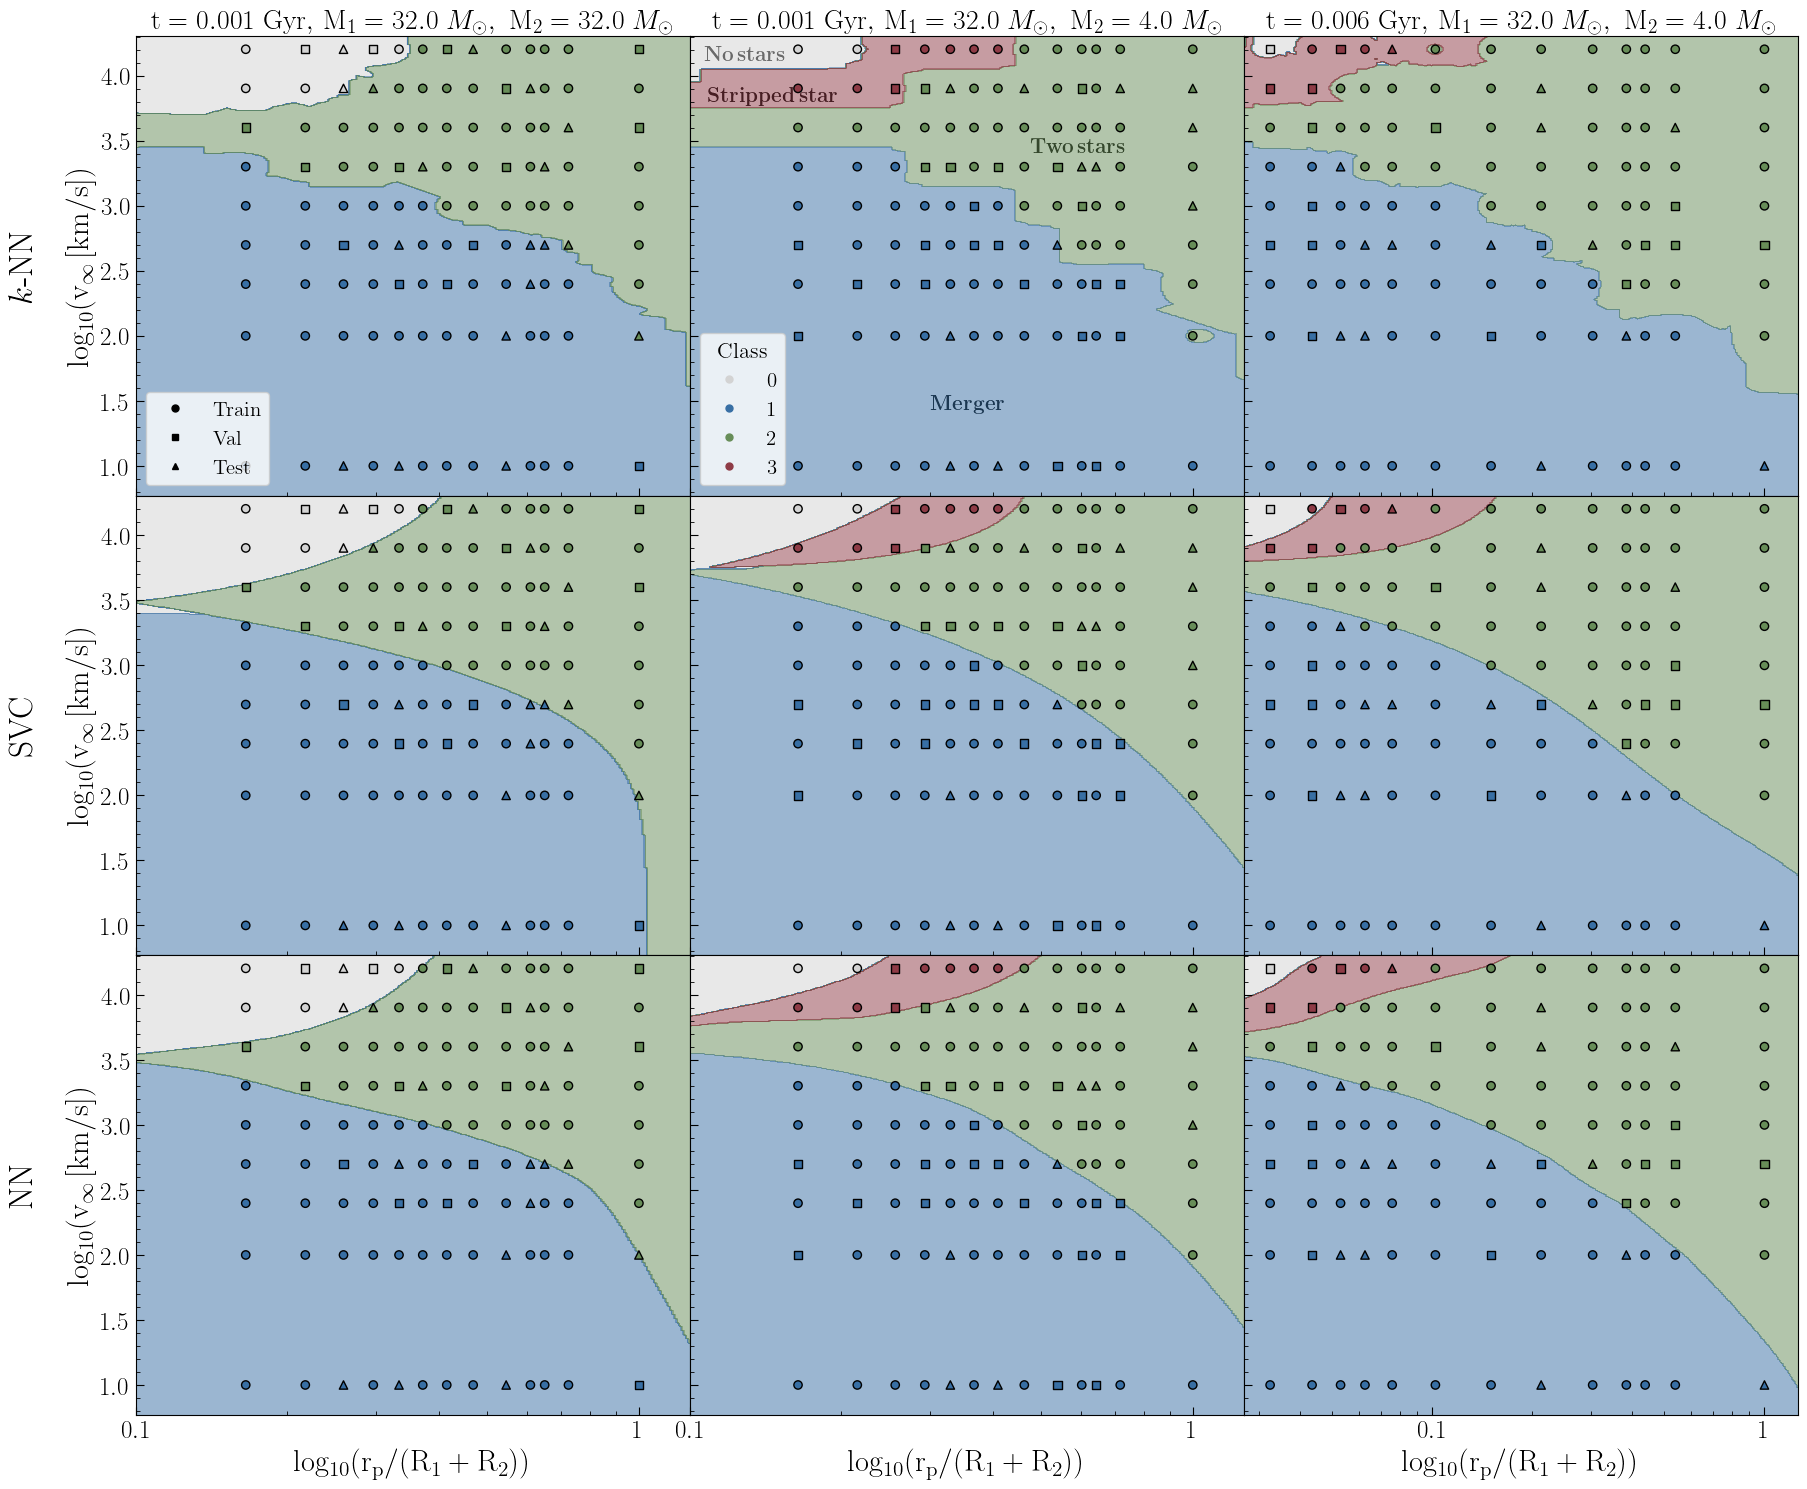

In [39]:
data = np.load('../data_splits_splot22f_1215.npz')
X_train = data['X_train']
y_train = data['y_train'][:, :1].flatten().astype(int)
X_val = data['X_val']
y_val = data['y_val'][:, :1].flatten().astype(int)
X_test = data['X_test']
y_test = data['y_test'][:, :1].flatten().astype(int)

unique_pairs = [[np.log10(0.001+ 0.001), np.log(32.), np.log(32.)], 
                [np.log10(0.001+ 0.001), np.log(32.), np.log(4.)], 
                [np.log10(0.006+ 0.001), np.log(32.), np.log(4.)]]

num_panels = 3
methods = ['kNN', 'SVC', 'NN']

num_rows = len(methods)
num_cols = num_panels

# Create figure and axes grid with only shared y-axis
fig, axes = plt.subplots(num_rows, num_cols, 
                         figsize=(6*num_cols, 5*num_rows), 
                         sharey=True)

# Ensure axes is 2D array
if num_rows == 1:
    axes = np.expand_dims(axes, 0)
if num_cols == 1:
    axes = np.expand_dims(axes, 1)

# Remove whitespace between subplots
plt.subplots_adjust(hspace=0, wspace=0)

# Define which panels get legends (row, col)
legend_panels = {
    (0, 0): [True, False],   # Top-left: data split legend
    (0, 1): [False, True],   # Top-right: class legend
}

# Loop over methods (rows) and unique pairs (columns)
for row_idx, method in enumerate(methods):
    for col_idx, unique in enumerate(unique_pairs):
        ax = axes[row_idx, col_idx]
        time, mass1, mass2 = unique[0], unique[1], unique[2]
        
        labels = [r'$\rm log_{10}(r_p / (R_1 + R_2))$', r'$\rm log_{10}(v_{\infty} \, [km/s])$', 
                  str(round(np.exp(mass1),0)), str(round(np.exp(mass2),0)), 
                  str(10**(time) - 0.001)]
        
        # Check if this panel should have legends
        legends = legend_panels.get((row_idx, col_idx), [False, False])
        
        # Plot using your function
        load_and_plot_SVC(ax, feature_idx=(1,2),
                         fixed_values={0: time, 3: mass1, 4: mass2},
                         labels=labels,
                         method=method,
                         legends=legends)
        
        # Only show title on top row
        if row_idx != 0:
            ax.set_title('')
        
        # Only show x-axis label on bottom row
        if row_idx != num_rows - 1:
            ax.set_xlabel('')
            ax.set_xticklabels([])  
        else:
            ax.set_xlabel(r'$\rm log_{10}(r_p / (R_1 + R_2))$', fontsize=22)
        
        # Only show y-axis label on leftmost column
        if col_idx != 0:
            ax.set_ylabel('')
        else:
            # Add y-axis label for leftmost column
            ax.set_ylabel(r'$\rm log_{10}(v_{\infty} \, [km/s])$', fontsize=22)

        # Increase tick label sizes
        ax.tick_params(axis='both', which='major', labelsize=18)
        
        # Add row method labels on the left side (closer to plot)
        if col_idx == 0:
            # Position text closer to the left of the axis
            if method == 'kNN':
                ax.text(-0.20, 0.5, r"$k$-$\rm NN$", transform=ax.transAxes, 
                   fontsize=24, va='center', ha='center', rotation=90, weight='bold')
            else:  
                ax.text(-0.20, 0.5, rf"$\rm {method}$", transform=ax.transAxes, 
                    fontsize=24, va='center', ha='center', rotation=90, weight='bold')

plt.tight_layout()
plt.subplots_adjust(hspace=0, wspace=0)
fig.savefig('../figures/decision_boundaries_classification.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

data = np.load('../data_splits_splot22f_1215.npz')
X_train = data['X_train']
y_train = data['y_train'][:, :1].flatten().astype(int)
X_val = data['X_val']
y_val = data['y_val'][:, :1].flatten().astype(int)
X_test = data['X_test']
y_test = data['y_test'][:, :1].flatten().astype(int)

from matplotlib.backends.backend_pdf import PdfPages

unique_pairs = np.unique(X_train[:, [0, 3, 4]], axis=0)


with PdfPages('boundary_plots.pdf') as pdf:

    for unique in unique_pairs:
        time, mass1, mass2 = unique[0], unique[1], unique[2]
        print('*'*60)
        print(time, mass1, mass2)
        labels = ['log10(b[RSUN])', 'log10(v_inf[km/s])', str(mass1), str(round(mass2,2))]
        labels = [r'$\rm r_p \, [R_{\odot}]$', r'$\rm Log_{10}(v_{inf} \, [km/s])$', 
                  str(round(np.exp(mass1),0)), str(round(np.exp(mass2),0)), 
                  str(10**(time) - 0.001)]
        
        fig = load_and_plot_SVC_old(feature_idx=(1, 2), 
                                fixed_values={0: time, 3: mass1, 4: mass2}, 
                                labels=labels, method='NN')

        if fig != None:
            # Save the current figure to the PDF
            pdf.savefig(fig, bbox_inches='tight')
            plt.show()
            plt.close(fig)



In [14]:
def load_and_plot_SVC_old(feature_idx, fixed_values={}, labels=[], method = 'kNN'):

    import joblib
    sys.path.insert(0, './NN/')

    import os
    print(os.getcwd())
    
    # --- Load saved model, scaler, and results ---

    data = np.load('../data_splits_splot22f_1206.npz')
    X_train = data['X_train']
    y_train = data['y_train'][:, :1].flatten().astype(int)
    X_val = data['X_val']
    y_val = data['y_val'][:, :1].flatten().astype(int)
    X_test = data['X_test']
    y_test = data['y_test'][:, :1].flatten().astype(int)

    
    if method == 'NN':
        from NN_classification import NeuralNetwork
        model_name = 'best_models/NN_best_model.pt'
        model = NeuralNetwork()
        checkpoint = torch.load(model_name, map_location=torch.device('cpu'))
        model.load_state_dict(checkpoint["model_state_dict"])
        scaler = [checkpoint["train_mean"], checkpoint["train_std"]]
        

    # --- Generate the plot ---
    fig = N_gridsearch_plotter_old(X_train, y_train, X_test, y_test, X_val, y_val,
                             model=model,
                             scaler=scaler,
                             feature_idx=feature_idx,
                             fixed_values=fixed_values,
                             labels=labels,
                             method = method)

    return fig

def N_gridsearch_plotter_old(X_train, y_train, X_test, y_test, X_val, y_val, model, scaler, feature_idx, fixed_values={}, labels = [], method = 'kNN', num_classes = 4):
    """
    Plots the decision boundary for a PyTorch model using a 2D slice of a higher-dimensional space.
    
    Parameters:
    - X_train, X_test, X_val: float arrays, containing (unnormalized) data for training, testing, and validation sets 
    - y_train, y_test, y_val: float arrays, containing (unnormalized) labels for training, testing, and validation sets 
    - model: Trained model.
    - scaler: to be used to transfor the data into the format taken by the model
    - feature_idx: Tuple (i, j) specifying which two features to plot.
    - fixed_values: Dictionary {feature_index: value} for fixing other dimensions. Unnormalized (same format as train/test/val tests)
    - labels:  list of strings 
    - method: method to evaluate
    """

    # Step 1: Filter train and test data based on fixed_values
    unique_times = np.unique(X_train[:,3])

    train_mask = np.logical_and.reduce([np.isclose(X_train[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    val_mask = np.logical_and.reduce([np.isclose(X_val[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    test_mask = np.logical_and.reduce([np.isclose(X_test[:, k], v, rtol=0.01) for k, v in fixed_values.items()])
    
    if (train_mask.sum() == 0 and test_mask.sum() == 0 and val_mask.sum() == 0):
        print("No data points!")
        return None

    X_train_filtered, y_train_filtered = X_train[train_mask], y_train[train_mask]
    X_val_filtered, y_val_filtered = X_val[val_mask], y_val[val_mask]
    X_test_filtered, y_test_filtered = X_test[test_mask], y_test[test_mask]
    
    # Step 2: Create a meshgrid for the chosen two features
    
    x_min, x_max = X_train_filtered[:, feature_idx[0]].min() - 0.1, X_train_filtered[:, feature_idx[0]].max() + 0.1
    y_min, y_max = X_train_filtered[:, feature_idx[1]].min() - 0.1, X_train_filtered[:, feature_idx[1]].max() + 0.1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))

    # Step 4: Standard normalize the data like you did before
    fixed_values_norm = {}
    if method == 'SVC' or method == 'kNN':
        xx_norm = (xx - scaler.mean_[feature_idx[0]]) / scaler.scale_[feature_idx[0]]
        yy_norm = (yy - scaler.mean_[feature_idx[1]]) / scaler.scale_[feature_idx[1]]

        # Scale the fixed values according to the method
        for k, v in fixed_values.items():
            fixed_values_norm[k] = (v - scaler.mean_[k]) / scaler.scale_[k]
        
    elif method == 'NN':
        train_mean = scaler[0]
        train_std = scaler[1]
        xx_norm = (xx - train_mean[feature_idx[0]]) / train_std[feature_idx[0]]
        yy_norm = (yy - train_mean[feature_idx[1]]) / train_std[feature_idx[1]]

        # Scale the fixed values according to the method
        for k, v in fixed_values.items():
            fixed_values_norm[k] = (v - train_mean[k]) / train_std[k]

    # Step 3: Construct full-dimensional input space for predictions
    X_vis = torch.zeros((xx_norm.ravel().shape[0], X_train.shape[1]), dtype=torch.float32)
    X_vis[:, feature_idx[0]] = torch.tensor(xx_norm.ravel(), dtype=torch.float32)
    X_vis[:, feature_idx[1]] = torch.tensor(yy_norm.ravel(), dtype=torch.float32)

    # Assign fixed values to other dimensions
    for k, v in fixed_values_norm.items():
        X_vis[:, k] = v

    # Step 4: Predict labels for meshgrid

    if method == 'SVC' or method == 'kNN':
        Z = model.predict(X_vis)
    elif method == 'NN':
        model.eval()
        with torch.no_grad():
            Z = model(X_vis).argmax(dim=1).numpy()

    Z = Z.reshape(xx.shape)

    # Normalize color mapping to match the scatter points and contour
    cmap = plt.cm.coolwarm  # Set the same colormap
    norm = mcolors.Normalize(vmin=0, vmax=2)  # Normalize colors

    if num_classes > 3: 

        cmap_base = plt.cm.coolwarm
        norm_base = mcolors.Normalize(vmin=0, vmax=2)
        # Build a list of colors by evaluating cmap for labels 0, 1, 2
        colors = [cmap_base(norm_base(i)) for i in range(3)]

        # Append a custom color for label 3 (e.g., green)
        colors.append((0.13, 0.55, 0.13, 1.0))  # green

        # Create a discrete colormap
        cmap = mcolors.ListedColormap(colors)

        # Define norm for discrete class labels 0–3
        norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5, 2.5, 3.5], ncolors=4)


    # Step 5: Plot decision boundary
    fig, ax = plt.subplots()
    plt.contourf(10**xx-0.1, np.log10(10**yy-10), Z, alpha=0.3, cmap=cmap, norm=norm)

    # print(X_train_filtered_unnorm[:, feature_idx[1]])

   
    plt.scatter(10**X_train_filtered[:, feature_idx[0]] -0.1, np.log10(10**X_train_filtered[:, feature_idx[1]]-10), c=y_train_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='o', label = 'Train')
    plt.scatter(10**X_val_filtered[:, feature_idx[0]] -0.1, np.log10(10**X_val_filtered[:, feature_idx[1]]-10), c=y_val_filtered, cmap=cmap, norm = norm, edgecolor="k", marker='s', label = 'Val')
    plt.scatter(10**X_test_filtered[:, feature_idx[0]]-0.1, np.log10(10**X_test_filtered[:, feature_idx[1]]-10), c=y_test_filtered, cmap=cmap, norm = norm, marker='^', label = 'Test' )
    plt.xlabel(fr" {labels[0]}", fontsize = 15)
    plt.ylabel(fr" {labels[1]}", fontsize = 15)
    plt.tick_params(axis='both', which='major', labelsize=13)  # or any size you prefer
    plt.legend()
    plt.title(
    fr"$\mathrm{{M_1}} = {labels[2]}\ M_\odot,\ \mathrm{{M_2}} = {labels[3]}\ M_\odot,\ \mathrm{{Time}} = {round((float(labels[4])),6)}\ \mathrm{{Gyr}}$", fontsize = 17)
    print(round((float(labels[4])),6))
    plt.tight_layout()
    return fig
    